# Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python in Jupyter Notebook
 
**Course:** 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term  
**Assignment:** Lab 1

**Dataset Source:** Data.gov, *Electric Vehicle Population Data*, published by data.wa.gov / State of Washington.  
**Dataset Page:** https://catalog.data.gov/dataset/electric-vehicle-population-data  
**CSV Download Used:** `https://data.wa.gov/resource/f6w7-q2d2.csv?$limit=20000`

This notebook analyzes an open-data dataset of Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) currently registered through the Washington State Department of Licensing.

## Step 1: Data Collection

The dataset was downloaded from Data.gov using the official CSV endpoint and saved as `wa_ev_population_data.csv`. The lab uses a 20,000-record CSV download from the public source so the notebook remains manageable while still using real open data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
source_url = "https://data.wa.gov/resource/f6w7-q2d2.csv?$limit=20000"
df = pd.read_csv("wa_ev_population_data.csv")
df.head()

,vin_1_10,county,city,state,zip_code,model_year,make,model,ev_type,cafv_type,electric_range,legislative_district,dol_vehicle_id,geocoded_column,electric_utility,_2020_census_tract
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,7SAYGDEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,1.0,260935657,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10


## Step 2: Data Visualization

The visualizations below explore EV adoption patterns, product makes, vehicle technology type, and electric range.

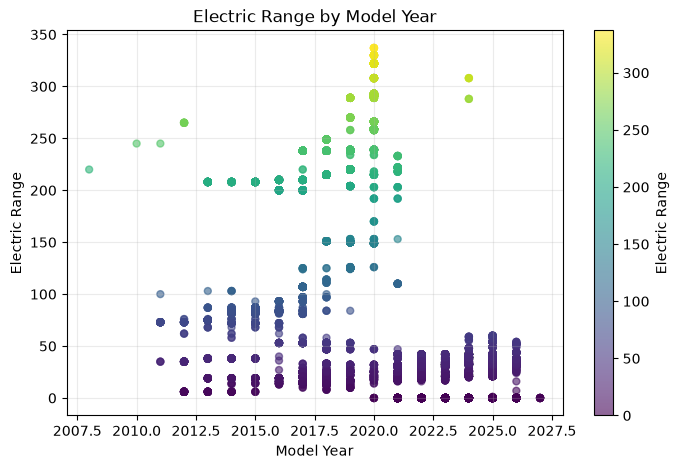

In [2]:
df_viz = df.copy()
for col in ["county", "city", "geocoded_column", "electric_utility"]:
    df_viz[col] = df_viz[col].fillna("Unknown")
for col in ["zip_code", "legislative_district", "_2020_census_tract"]:
    df_viz[col] = df_viz[col].fillna(df_viz[col].median())

plt.figure(figsize=(8, 5))
scatter = plt.scatter(df_viz["model_year"], df_viz["electric_range"], c=df_viz["electric_range"], cmap="viridis", s=25, alpha=0.6)
plt.colorbar(scatter, label="Electric Range")
plt.title("Electric Range by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Electric Range")
plt.grid(alpha=0.25)
plt.show()

**Insight:** Many newer vehicles have an electric range value of `0`, which the dataset's CAFV labels indicate often means range has not yet been researched. Older BEVs and some PHEVs show a wide spread of reported ranges.

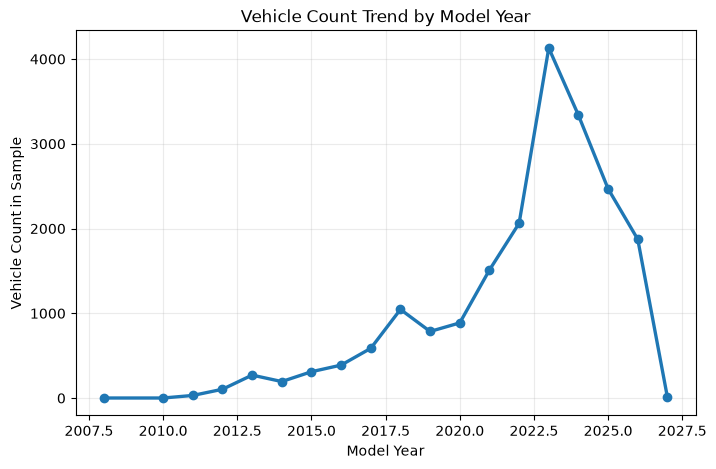

In [3]:
year_counts = df_viz.groupby("model_year").size().reset_index(name="vehicle_count").sort_values("model_year")
plt.figure(figsize=(8, 5))
plt.plot(year_counts["model_year"], year_counts["vehicle_count"], marker="o", linewidth=2.4)
plt.title("Vehicle Count Trend by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Vehicle Count in Sample")
plt.grid(alpha=0.25)
plt.show()

**Insight:** The sample contains many recent model years, showing that EV registrations in the dataset are concentrated in newer vehicles.

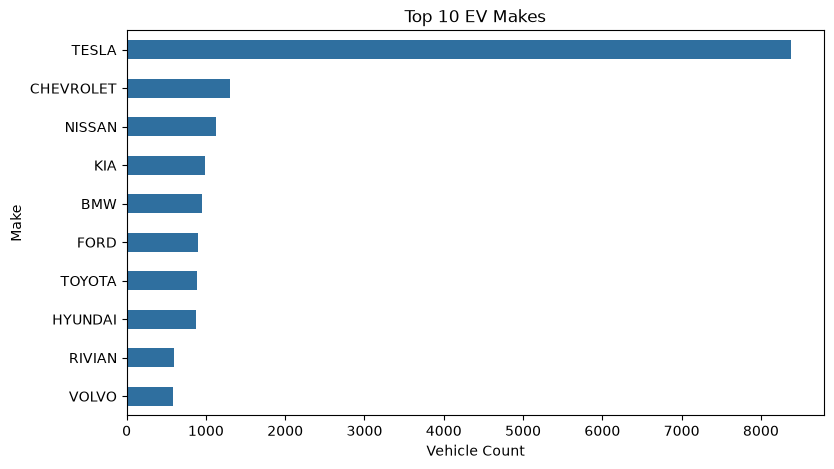

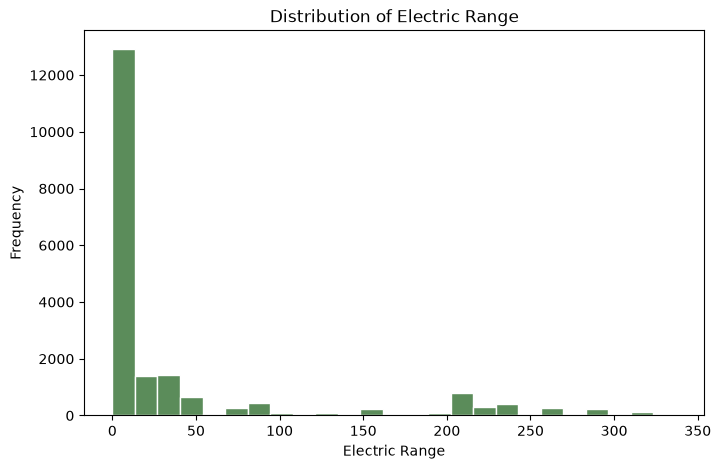

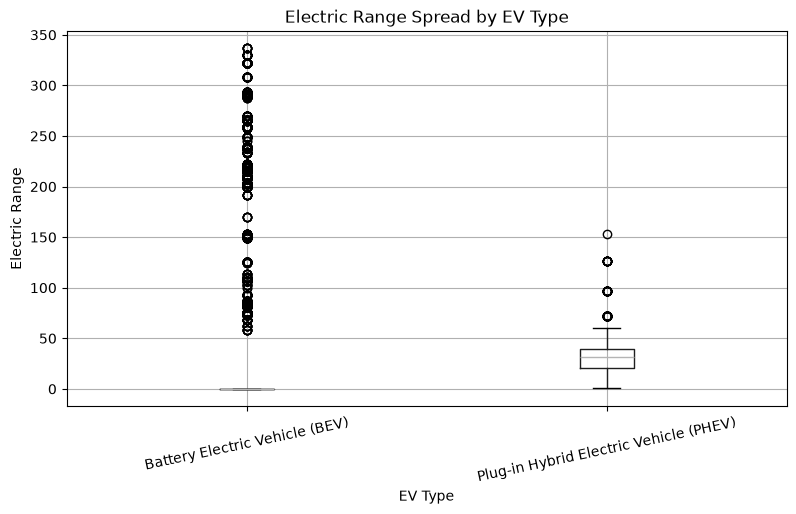

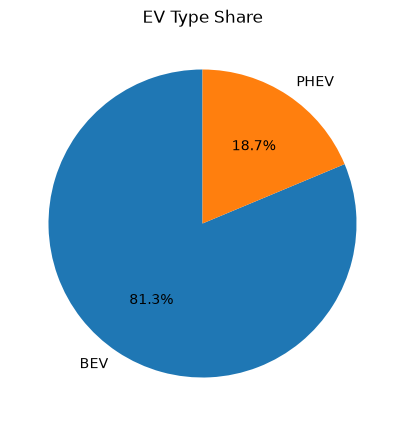

In [4]:
df_viz["make"].value_counts().head(10).sort_values().plot(kind="barh", figsize=(9, 5), color="#2f6f9f")
plt.title("Top 10 EV Makes")
plt.xlabel("Vehicle Count")
plt.ylabel("Make")
plt.show()

df_viz["electric_range"].plot(kind="hist", bins=25, figsize=(8, 5), color="#5b8c5a", edgecolor="white")
plt.title("Distribution of Electric Range")
plt.xlabel("Electric Range")
plt.ylabel("Frequency")
plt.show()

df_viz.boxplot(column="electric_range", by="ev_type", figsize=(9, 5), rot=12)
plt.title("Electric Range Spread by EV Type")
plt.suptitle("")
plt.xlabel("EV Type")
plt.ylabel("Electric Range")
plt.show()

ev_counts = df_viz["ev_type"].value_counts()
labels = ["BEV" if "Battery" in item else "PHEV" for item in ev_counts.index]
ev_counts.plot(kind="pie", labels=labels, autopct="%1.1f%%", figsize=(7, 5), startangle=90)
plt.title("EV Type Share")
plt.ylabel("")
plt.show()

## Step 3: Data Preprocessing

### 3.1 Handling Missing Values

The dataset contains missing values in location and legislative/geographic fields. Categorical fields are filled with `Unknown`; numeric geography fields are filled with their medians.

In [5]:
missing_before = df.isna().sum().sort_values(ascending=False)
missing_rows_before = df[df.isna().any(axis=1)]
missing_before.head(10), missing_rows_before.head()

(legislative_district    3
 county                  2
 city                    2
 zip_code                2
 geocoded_column         2
 electric_utility        2
 _2020_census_tract      2
 vin_1_10                0
 state                   0
 model_year              0
 dtype: int64,
        vin_1_10 county  city state  zip_code  model_year   make    model  \
 401  5YJ3E1EA4J   Yuma  Yuma    AZ   85364.0        2018  TESLA  MODEL 3   
 420  7SAYGDEE9N    NaN   NaN    BC       NaN        2022  TESLA  MODEL Y   
 455  5YJ3E1EA5S    NaN   NaN    BC       NaN        2025  TESLA  MODEL 3   
 
                             ev_type  \
 401  Battery Electric Vehicle (BEV)   
 420  Battery Electric Vehicle (BEV)   
 455  Battery Electric Vehicle (BEV)   
 
                                              cafv_type  electric_range  \
 401            Clean Alternative Fuel Vehicle Eligible             215   
 420  Eligibility unknown as battery range has not b...               0   
 455  Eligibility 

In [6]:
df_clean = df.copy()
for col in ["county", "city", "geocoded_column", "electric_utility"]:
    df_clean[col] = df_clean[col].fillna("Unknown")
for col in ["zip_code", "legislative_district", "_2020_census_tract"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
missing_after = df_clean.isna().sum().sort_values(ascending=False)
missing_rows_after = df_clean.loc[missing_rows_before.head().index]
missing_after.head(10), missing_rows_after

(vin_1_10      0
 county        0
 city          0
 state         0
 zip_code      0
 model_year    0
 make          0
 model         0
 ev_type       0
 cafv_type     0
 dtype: int64,
        vin_1_10   county     city state  zip_code  model_year   make    model  \
 401  5YJ3E1EA4J     Yuma     Yuma    AZ   85364.0        2018  TESLA  MODEL 3   
 420  7SAYGDEE9N  Unknown  Unknown    BC   98105.0        2022  TESLA  MODEL Y   
 455  5YJ3E1EA5S  Unknown  Unknown    BC   98105.0        2025  TESLA  MODEL 3   
 
                             ev_type  \
 401  Battery Electric Vehicle (BEV)   
 420  Battery Electric Vehicle (BEV)   
 455  Battery Electric Vehicle (BEV)   
 
                                              cafv_type  electric_range  \
 401            Clean Alternative Fuel Vehicle Eligible             215   
 420  Eligibility unknown as battery range has not b...               0   
 455  Eligibility unknown as battery range has not b...               0   
 
      legislative_dis

### 3.2 Outlier Detection and Removal

The IQR calculation is shown for non-zero `electric_range` values. IQR finds no outliers in this real data slice, so the assignment's allowed standard deviation method is then used for outlier handling. Zero is treated separately because many newer vehicles use 0 when range has not been researched.

In [7]:
range_nonzero = df_clean[df_clean["electric_range"] > 0]["electric_range"]
q1 = range_nonzero.quantile(0.25)
q3 = range_nonzero.quantile(0.75)
iqr = q3 - q1
lower_iqr = q1 - 1.5 * iqr
upper_iqr = q3 + 1.5 * iqr
iqr_outliers = df_clean[(df_clean["electric_range"] > 0) & ((df_clean["electric_range"] < lower_iqr) | (df_clean["electric_range"] > upper_iqr))]

range_mean = range_nonzero.mean()
range_std = range_nonzero.std()
lower_std = range_mean - 2 * range_std
upper_std = range_mean + 2 * range_std
outlier_mask = (df_clean["electric_range"] > 0) & ((df_clean["electric_range"] < lower_std) | (df_clean["electric_range"] > upper_std))
outliers = df_clean[outlier_mask]
df_no_outliers = df_clean[~outlier_mask].copy()

outlier_summary = pd.DataFrame({
    "Metric": ["IQR Q1", "IQR Q3", "IQR", "IQR Lower Bound", "IQR Upper Bound", "IQR Outlier Count", "Mean", "Std Dev", "Std Lower Bound", "Std Upper Bound", "Std Outlier Count"],
    "Value": [q1, q3, iqr, lower_iqr, upper_iqr, len(iqr_outliers), range_mean, range_std, lower_std, upper_std, len(outliers)]
})
outlier_summary, outliers[["county", "city", "model_year", "make", "model", "ev_type", "electric_range"]].head(), df_no_outliers.head()

(               Metric       Value
 0              IQR Q1   32.000000
 1              IQR Q3  215.000000
 2                 IQR  183.000000
 3     IQR Lower Bound -242.500000
 4     IQR Upper Bound  489.500000
 5   IQR Outlier Count    0.000000
 6                Mean  111.709121
 7             Std Dev   97.365140
 8     Std Lower Bound  -83.021158
 9     Std Upper Bound  306.439401
 10  Std Outlier Count  182.000000,
       county               city  model_year   make    model  \
 22    Kitsap  Bainbridge Island        2020  TESLA  MODEL 3   
 28      King            Redmond        2020  TESLA  MODEL 3   
 46      King             Duvall        2020  TESLA  MODEL 3   
 52  Thurston           Tumwater        2020  TESLA  MODEL 3   
 68      King            Seattle        2020  TESLA  MODEL 3   
 
                            ev_type  electric_range  
 22  Battery Electric Vehicle (BEV)             322  
 28  Battery Electric Vehicle (BEV)             322  
 46  Battery Electric Vehicle (

### 3.3 Data Reduction

The data is reduced by sampling 20% of the rows and dropping high-cardinality identifier/geocoding fields that are less useful for this lab analysis.

In [8]:
before_reduction = df_no_outliers.copy()
sampled = df_no_outliers.sample(frac=0.20, random_state=42).reset_index(drop=True)
reduced = sampled.drop(columns=["vin_1_10", "dol_vehicle_id", "geocoded_column", "_2020_census_tract"]).copy()
before_reduction.head(), reduced.head()

(     vin_1_10     county          city state  zip_code  model_year   make  \
 0  YV4H60PE7S     Kitsap     Bremerton    WA   98310.0        2025  VOLVO   
 1  5YJ3E1EB3K  Snohomish      Lynnwood    WA   98087.0        2019  TESLA   
 2  1FADP5CUXD     Kitsap  Port Orchard    WA   98367.0        2013   FORD   
 3  5YJSA1H20E   Thurston          Yelm    WA   98597.0        2014  TESLA   
 4  7SAYGDEE2P  Snohomish       Bothell    WA   98012.0        2023  TESLA   
 
      model                                 ev_type  \
 0     XC90  Plug-in Hybrid Electric Vehicle (PHEV)   
 1  MODEL 3          Battery Electric Vehicle (BEV)   
 2    C-MAX  Plug-in Hybrid Electric Vehicle (PHEV)   
 3  MODEL S          Battery Electric Vehicle (BEV)   
 4  MODEL Y          Battery Electric Vehicle (BEV)   
 
                                            cafv_type  electric_range  \
 0            Clean Alternative Fuel Vehicle Eligible              32   
 1            Clean Alternative Fuel Vehicle Eligibl

### 3.4 Data Scaling and Discretization

Min-Max scaling is applied to `electric_range`, Z-score standardization is applied to `model_year`, and electric range is grouped into meaningful categories.

In [9]:
before_scaling = reduced[["model_year", "make", "model", "electric_range"]].copy()
reduced["Electric_Range_MinMax"] = (reduced["electric_range"] - reduced["electric_range"].min()) / (reduced["electric_range"].max() - reduced["electric_range"].min())
reduced["Model_Year_ZScore"] = (reduced["model_year"] - reduced["model_year"].mean()) / reduced["model_year"].std(ddof=0)
reduced["Range_Category"] = pd.cut(reduced["electric_range"], bins=[-1, 0, 50, 150, 400], labels=["Unknown/Not Researched", "Short", "Medium", "Long"])
before_scaling.head(), reduced[["model_year", "electric_range", "Electric_Range_MinMax", "Model_Year_ZScore", "Range_Category"]].head()

(   model_year           make            model  electric_range
 0        2024          TESLA          MODEL X               0
 1        2026          TESLA          MODEL 3               0
 2        2022  MERCEDES-BENZ  EQS-CLASS SEDAN               0
 3        2016           AUDI               A3              16
 4        2023          TESLA          MODEL Y               0,
    model_year  electric_range  Electric_Range_MinMax  Model_Year_ZScore  \
 0        2024               0               0.000000           0.590467   
 1        2026               0               0.000000           1.229803   
 2        2022               0               0.000000          -0.048870   
 3        2016              16               0.054608          -1.966878   
 4        2023               0               0.000000           0.270799   
 
            Range_Category  
 0  Unknown/Not Researched  
 1  Unknown/Not Researched  
 2  Unknown/Not Researched  
 3                   Short  
 4  Unknown/Not Re

In [10]:
reduced.to_csv("wa_ev_population_data_cleaned.csv", index=False)

## Step 4: Statistical Analysis

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   vin_1_10              20000 non-null  str    
 1   county                19998 non-null  str    
 2   city                  19998 non-null  str    
 3   state                 20000 non-null  str    
 4   zip_code              19998 non-null  float64
 5   model_year            20000 non-null  int64  
 6   make                  20000 non-null  str    
 7   model                 20000 non-null  str    
 8   ev_type               20000 non-null  str    
 9   cafv_type             20000 non-null  str    
 10  electric_range        20000 non-null  int64  
 11  legislative_district  19997 non-null  float64
 12  dol_vehicle_id        20000 non-null  int64  
 13  geocoded_column       19998 non-null  str    
 14  electric_utility      19998 non-null  str    
 15  _2020_census_tract    19998 no

In [12]:
df.describe()

,zip_code,model_year,electric_range,legislative_district,dol_vehicle_id,_2020_census_tract
count,19998.000000,20000.000000,20000.000000,19997.000000,2.000000e+04,1.999800e+04
mean,98186.855386,2022.153450,40.170600,33.997900,2.476961e+08,5.303093e+10
std,251.355238,3.091437,79.262746,14.111489,6.536173e+07,3.467704e+08
min,85364.000000,2008.000000,0.000000,1.000000,1.100570e+05,4.027001e+09
25%,98033.000000,2021.000000,0.000000,23.000000,2.212267e+08,5.303301e+10
50%,98105.000000,2023.000000,0.000000,41.000000,2.646982e+08,5.303302e+10
75%,98178.000000,2024.000000,33.000000,46.000000,2.819042e+08,5.303303e+10
max,99362.000000,2027.000000,337.000000,49.000000,4.789259e+08,5.307794e+10


### 4.2 Central Tendency Measures

In [13]:
central_tendency = pd.DataFrame({
    "Metric": ["Minimum", "Maximum", "Mean", "Median", "Mode"],
    "Model Year": [df_clean["model_year"].min(), df_clean["model_year"].max(), df_clean["model_year"].mean(), df_clean["model_year"].median(), df_clean["model_year"].mode().iloc[0]],
    "Electric Range": [df_clean["electric_range"].min(), df_clean["electric_range"].max(), df_clean["electric_range"].mean(), df_clean["electric_range"].median(), df_clean["electric_range"].mode().iloc[0]],
    "Legislative District": [df_clean["legislative_district"].min(), df_clean["legislative_district"].max(), df_clean["legislative_district"].mean(), df_clean["legislative_district"].median(), df_clean["legislative_district"].mode().iloc[0]],
}).round(2)
central_tendency

,Metric,Model Year,Electric Range,Legislative District
0,Minimum,2008.00,0.00,1.0
1,Maximum,2027.00,337.00,49.0
2,Mean,2022.15,40.17,34.0
3,Median,2023.00,0.00,41.0
4,Mode,2023.00,0.00,48.0


### 4.3 Dispersion Measures

In [14]:
analysis_cols = ["model_year", "electric_range", "legislative_district"]
quartiles = df_clean[analysis_cols].quantile([0.25, 0.5, 0.75]).T
quartiles.columns = ["Q1", "Median", "Q3"]
dispersion = pd.DataFrame({
    "Range": df_clean[analysis_cols].max() - df_clean[analysis_cols].min(),
    "Q1": quartiles["Q1"],
    "Q3": quartiles["Q3"],
    "IQR": quartiles["Q3"] - quartiles["Q1"],
    "Variance": df_clean[analysis_cols].var(),
    "Standard Deviation": df_clean[analysis_cols].std(),
}).round(2)
dispersion

,Range,Q1,Q3,IQR,Variance,Standard Deviation
model_year,19.0,2021.0,2024.0,3.0,9.56,3.09
electric_range,337.0,0.0,33.0,33.0,6282.58,79.26
legislative_district,48.0,23.0,46.0,23.0,199.11,14.11


### 4.4 Correlation Analysis

In [15]:
corr_cols = ["zip_code", "model_year", "electric_range", "legislative_district", "dol_vehicle_id", "_2020_census_tract"]
correlation_matrix = df_clean[corr_cols].corr(numeric_only=True).round(2)
correlation_matrix

,zip_code,model_year,electric_range,legislative_district,dol_vehicle_id,_2020_census_tract
zip_code,1.00,-0.06,0.03,-0.40,-0.01,0.36
model_year,-0.06,1.00,-0.56,0.04,0.34,0.01
electric_range,0.03,-0.56,1.00,-0.02,-0.20,-0.01
legislative_district,-0.40,0.04,-0.02,1.00,0.00,-0.01
dol_vehicle_id,-0.01,0.34,-0.20,0.00,1.00,-0.01
_2020_census_tract,0.36,0.01,-0.01,-0.01,-0.01,1.00


## Summary of Findings

- The dataset was downloaded from Data.gov and contains real Washington State EV registration records.
- Battery Electric Vehicles account for most records in this sample.
- Tesla is one of the dominant makes in the sample, followed by several other EV manufacturers.
- Reported electric range varies widely, and many newer records show `0` because range has not yet been researched.
- Missing values were concentrated in location/geography fields and were handled with `Unknown` or median replacement.
- The IQR calculation found no electric-range outliers in the non-zero range values, so a two-standard-deviation threshold was used to identify and remove unusually high range records.